# Introduction

This project focuses on building a machine‑learning model to classify IMDB movie reviews as positive or negative. The Film Junky Union wants to automatically detect negative reviews to support content moderation and improve user experience. The dataset includes labeled reviews already split into train and test sets.

The goal is to preprocess the text, vectorize it, train multiple models, and achieve an F1 score of at least 0.85 on the test set.

## Project Objective

Build and evaluate several text‑classification models using different preprocessing strategies:

- Basic normalization

- Stopword removal

- Lemmatization

- TF‑IDF vectorization

- Logistic Regression

- LightGBM

The final deliverable is a model that meets the performance threshold and generalizes well to unseen reviews.

## Initialization

In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

import nltk
import spacy
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn')

## Load Data

In [3]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [4]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## Exploratory Data Analysis (EDA)

In this section, I explore trends in movie releases, review activity over time, and the distribution of review counts per movie. This helps identify patterns, anomalies, and potential issues before modeling.


### Movies and Reviews Over Time

The first plot shows how many movies were released each year.  
The second plot shows the number of positive and negative reviews per year, along with a rolling 5‑year average of reviews per movie.  
This helps identify trends, spikes, or gaps in the dataset.


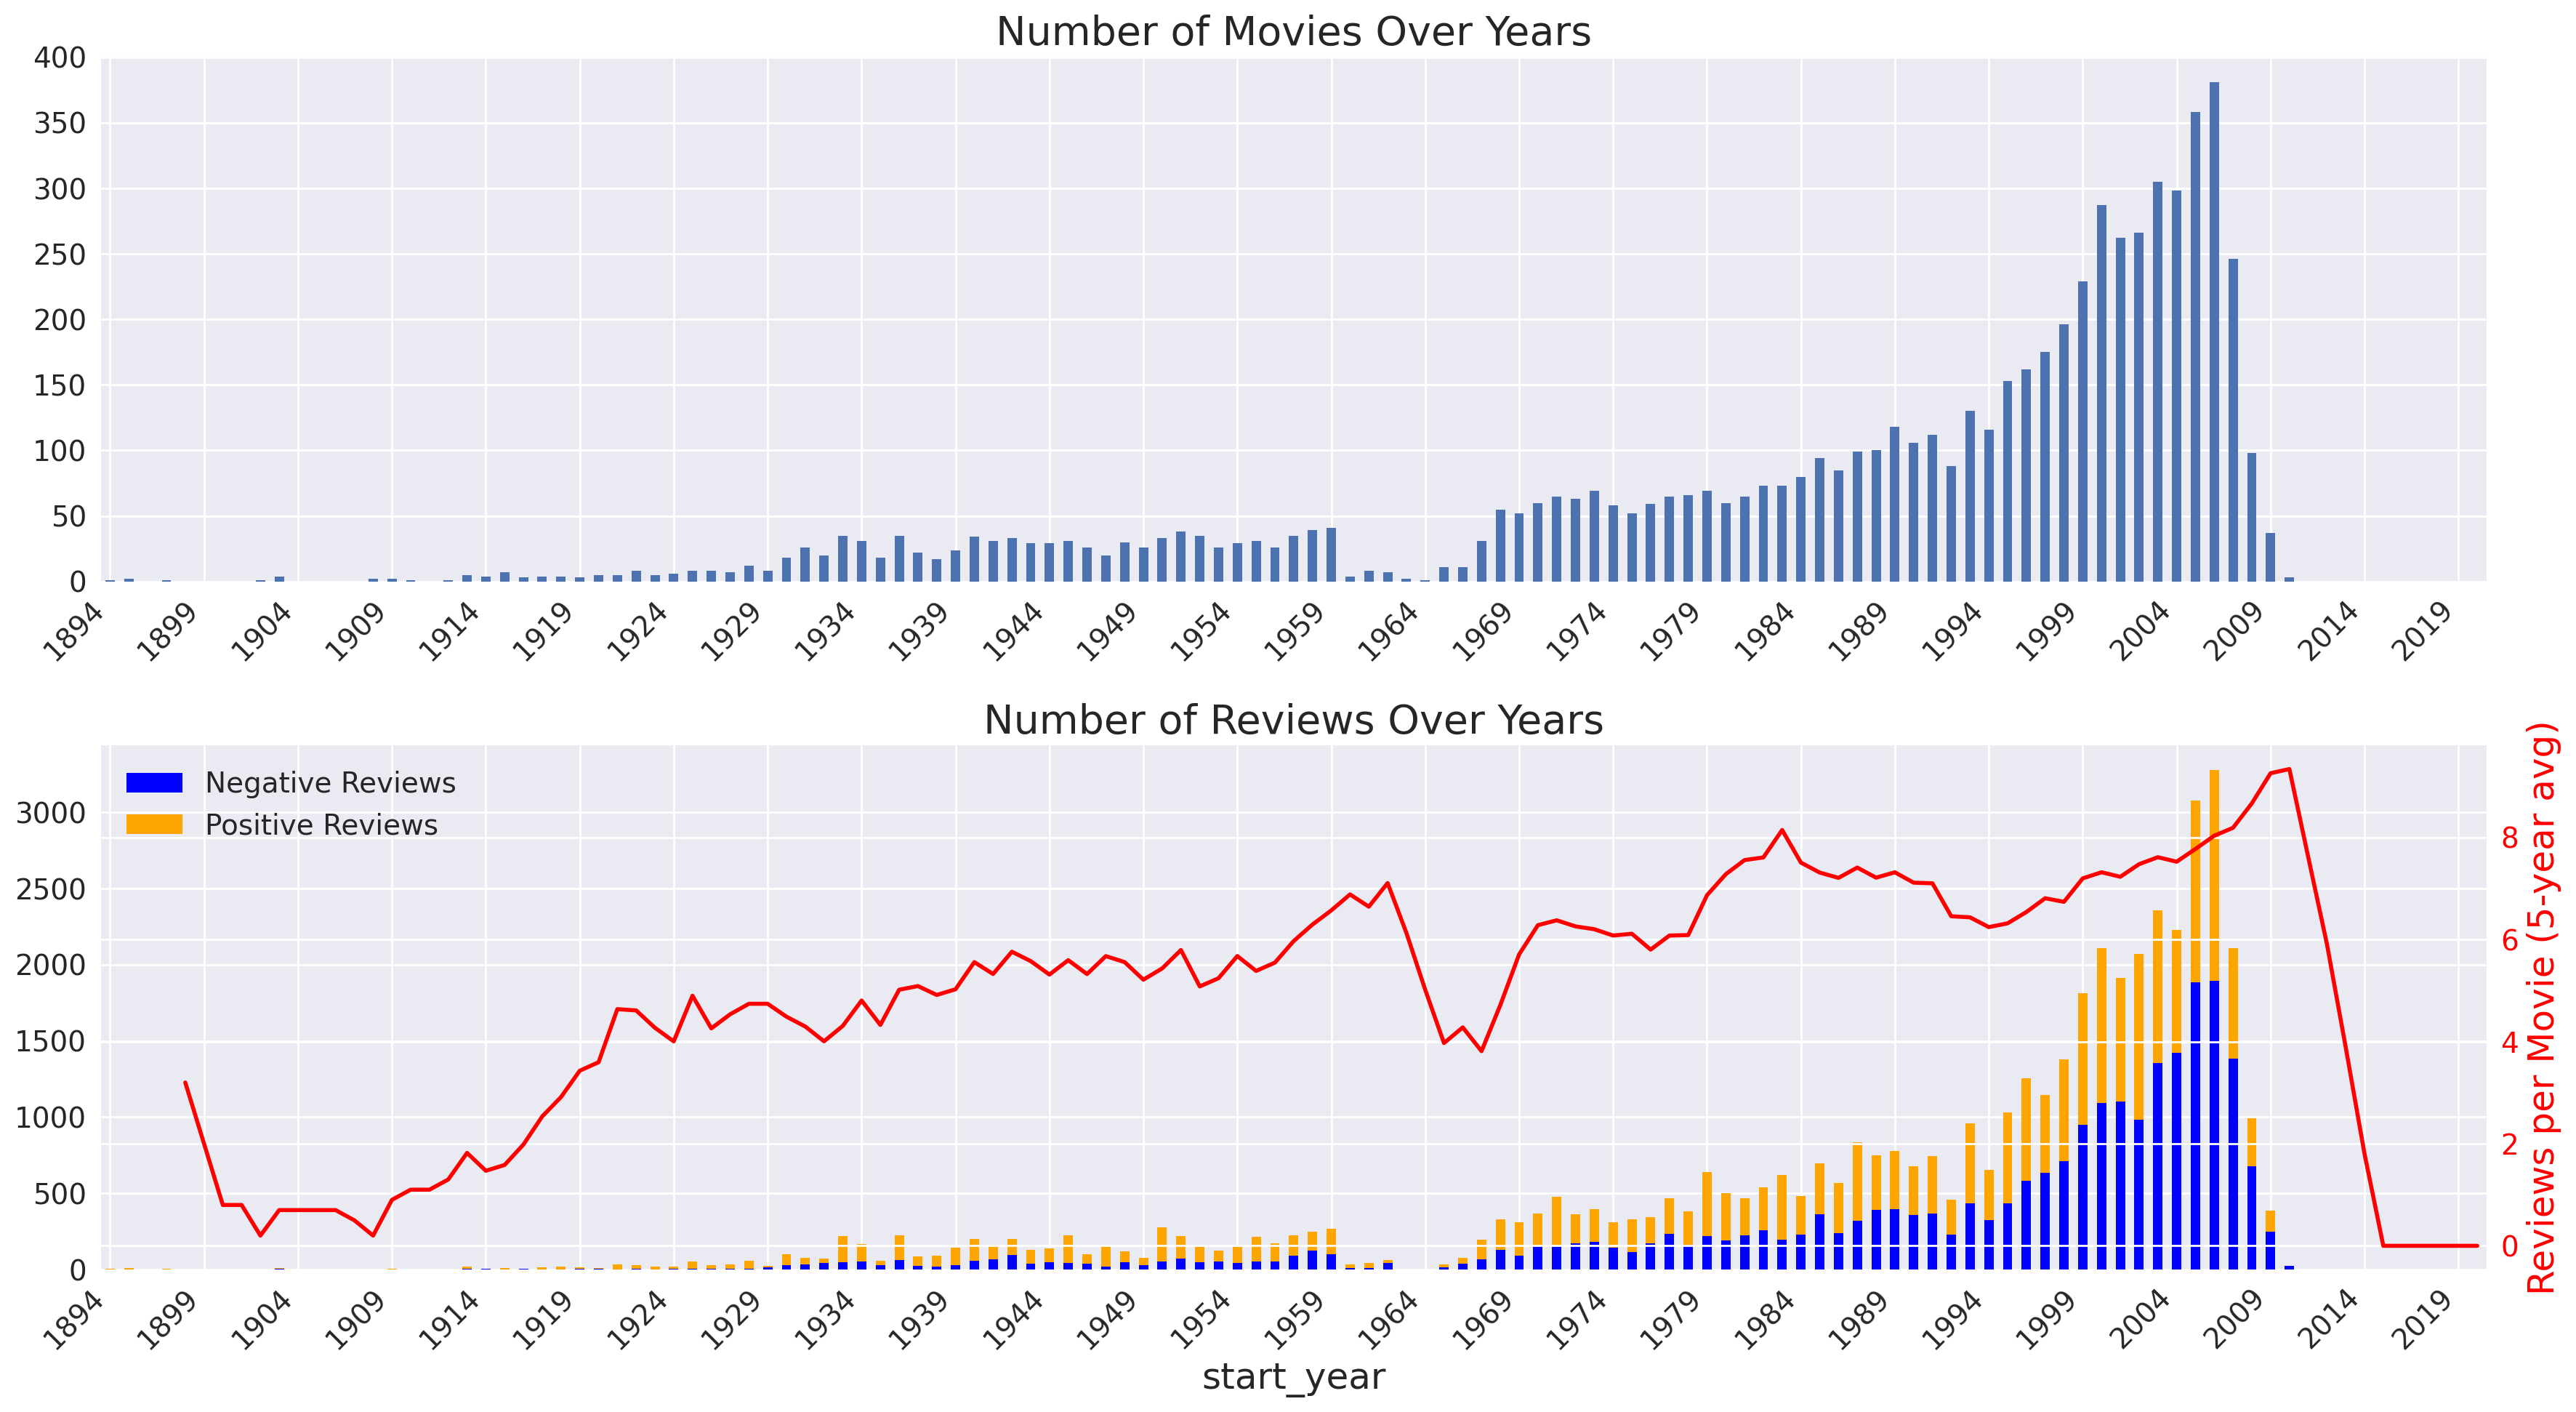

In [5]:
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

fig, axs = plt.subplots(2, 1, figsize=(18, 10))

ax = axs[0]
dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]
dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft2.columns = ['Negative Reviews', 'Positive Reviews']

dft2.plot(kind='bar', stacked=True, ax=ax, color=['blue', 'orange'])

dft2_total = df_reviews['start_year'].value_counts().sort_index()
dft2_total = dft2_total.reindex(index=np.arange(dft2_total.index.min(), max(dft2_total.index.max(), 2021))).fillna(0)
dft3 = (dft2_total/dft1).fillna(0)
axt = ax.twinx()
axt.set_ylabel('Reviews per Movie (5-year avg)', color='red')
axt.tick_params(axis='y', labelcolor='red')
dft3.reset_index(drop=True).rolling(5).mean().plot(color='red', linewidth=2, label='_nolegend_', ax=axt)

bar_handles, bar_labels = ax.get_legend_handles_labels()
line_handles, line_labels = axt.get_legend_handles_labels()
ax.legend(bar_handles + line_handles, bar_labels + line_labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

for ax in axs:
    ticks = ax.get_xticks()
    new_ticks = ticks[::5]
    ax.set_xticks(new_ticks)

plt.setp(axs[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()

### Distribution of Reviews Per Movie

Here I examine how many reviews each movie receives.  
The bar plot shows exact counts, while the KDE plot shows the smoothed distribution.  
This helps identify whether the dataset is balanced or dominated by movies with very few reviews.


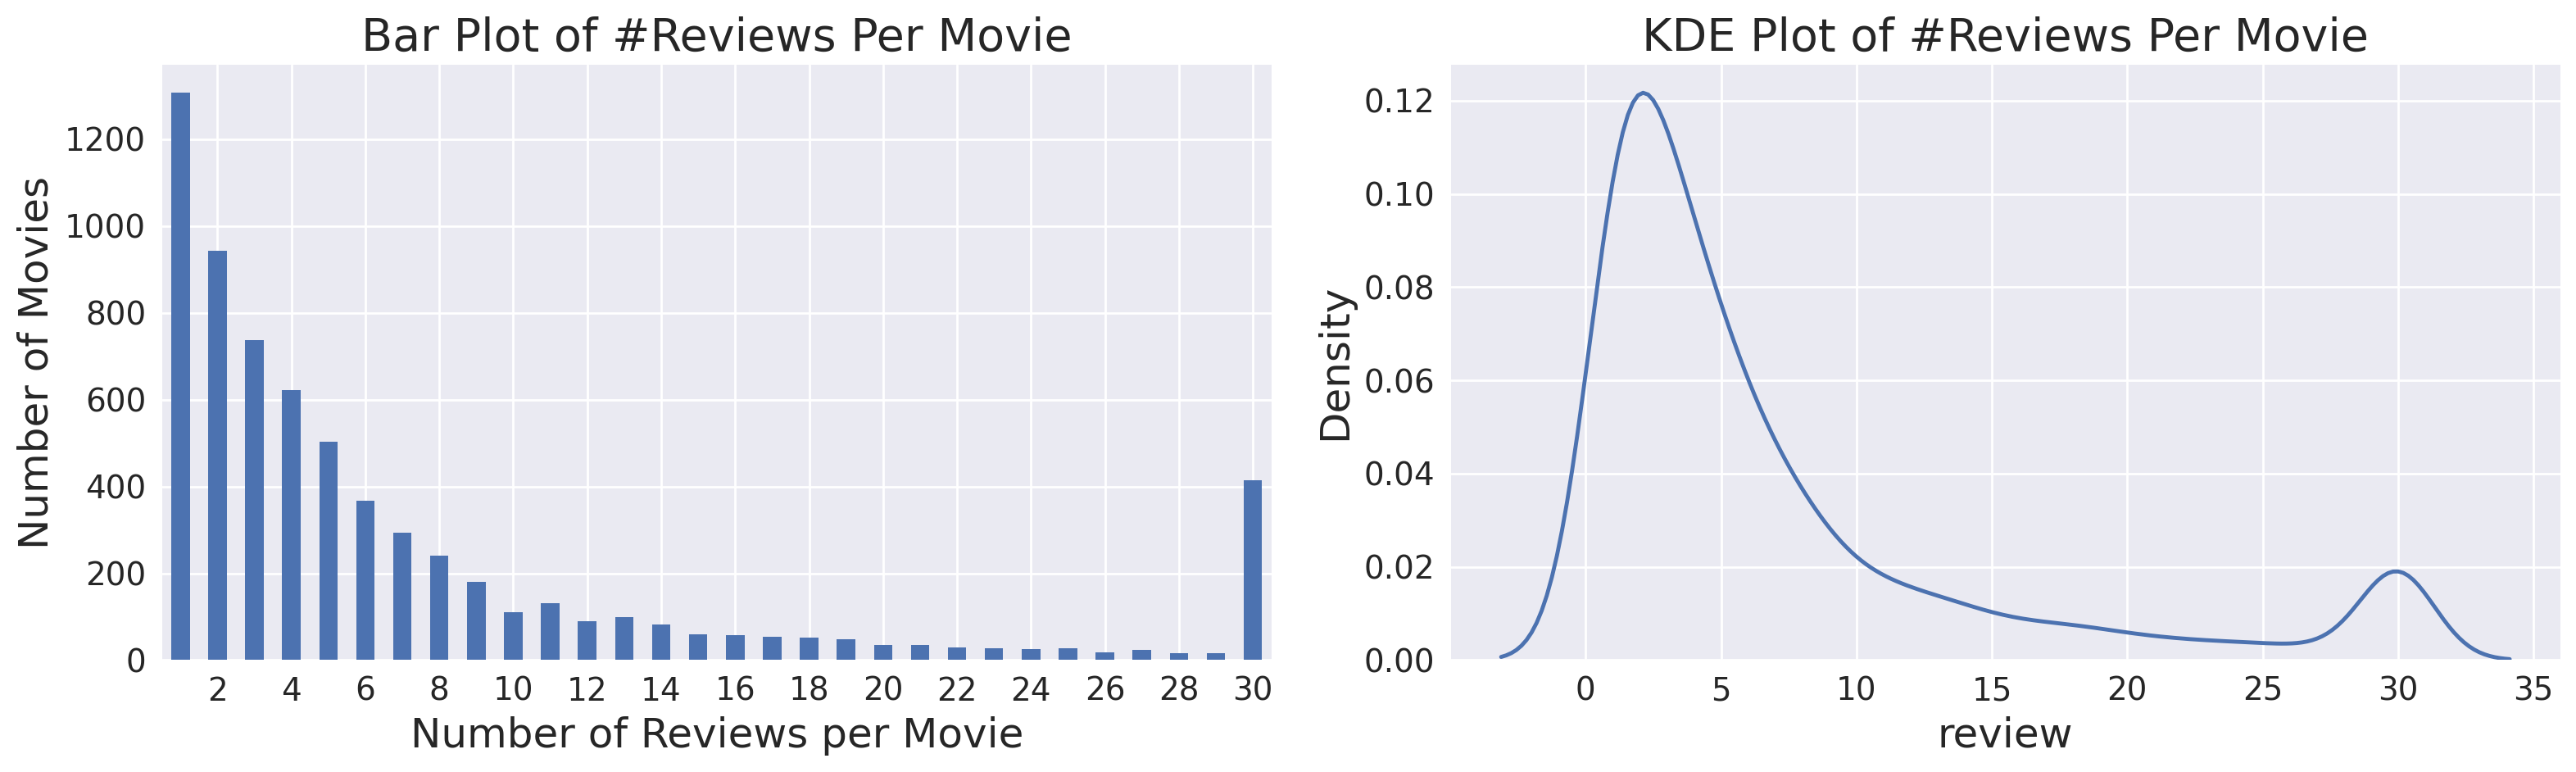

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_xticks(range(1, 30, 2))
ax.set_xlabel('Number of Reviews per Movie')
ax.set_ylabel('Number of Movies') 
ax.tick_params(axis='x', rotation=0)

ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

### Investigating the Spike at 30 Reviews

There appears to be an unusual number of movies with exactly 30 reviews.  
To understand this anomaly, I identify which movies have exactly 30 reviews and inspect their data.

In [7]:
movies_30_reviews = df_reviews.groupby('tconst')['review'].count()
movies_with_30 = movies_30_reviews[movies_30_reviews == 30].index

movies_30_details = df_reviews[df_reviews['tconst'].isin(movies_with_30)][
    ['tconst', 'primary_title', 'start_year', 'genres', 'average_rating']
].drop_duplicates()

print(f"Number of movies with exactly 30 reviews: {len(movies_30_details)}")
print(f"Sample of movies with 30 reviews:")
print(movies_30_details.head(10))

Number of movies with exactly 30 reviews: 415
Sample of movies with 30 reviews:
        tconst               primary_title  start_year  \
43   tt0499603            10 Items or Less        2006   
114  tt0114746                  12 Monkeys        1995   
251  tt0062622       2001: A Space Odyssey        1968   
295  tt0472582                        2:37        2006   
478  tt0312318                        9/11        2002   
541  tt0120623                A Bug's Life        1998   
639  tt0088915               A Chorus Line        1985   
669  tt0087056           A Christmas Carol        1984   
880  tt0295289                 A Guy Thing        2003   
941  tt0038733  A Matter of Life and Death        1946   

                         genres  average_rating  
43                 Comedy,Drama             6.6  
114     Mystery,Sci-Fi,Thriller             8.0  
251            Adventure,Sci-Fi             8.3  
295                       Drama             6.8  
478                 Documentary

In [8]:
review_counts = df_reviews.groupby('tconst')['review'].count()
print("Distribution of review counts:")
print(review_counts.value_counts().sort_index().tail(10))
print(f"\nMovies with more than 30 reviews: {(review_counts > 30).sum()}")
print(f"Maximum number of reviews per movie: {review_counts.max()}")

Distribution of review counts:
21     35
22     29
23     28
24     25
25     28
26     17
27     24
28     16
29     16
30    415
Name: review, dtype: int64

Movies with more than 30 reviews: 0
Maximum number of reviews per movie: 30


### Class Balance Check

Here I check how many positive vs. negative reviews are present in the dataset.


In [9]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

## Normalization

All models in this project expect the text to be normalized.  
I convert all reviews to lowercase, remove digits and punctuation, collapse extra spaces, and strip whitespace.


In [10]:
df_reviews['review_norm'] = df_reviews['review'] \
    .str.lower() \
    .str.replace(r'[^a-z\s]', ' ', regex=True) \
    .str.replace(r'\s+', ' ', regex=True) \
    .str.strip()

## Train / Test Split

The dataset already includes a predefined train/test split using the `ds_part` column.  
I separate the data into training and test subsets and extract the target variable (`pos`) for both.


In [11]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


### TF‑IDF Vectorization

I convert the normalized text into numerical features using TF‑IDF with up to 50,000 features and both unigrams and bigrams.  
The vectorizer is fit on the training data and applied to the test data.


In [12]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english'
)

train_features = vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features = vectorizer.transform(df_reviews_test['review_norm'])

train_features.shape, test_features.shape

((23796, 50000), (23535, 50000))

### Model Evaluation Function

I define a reusable evaluation function that computes and visualizes key metrics:
- F1 score across thresholds  
- ROC curve and ROC AUC  
- Precision‑Recall curve and Average Precision Score  
- Accuracy and F1 for train and test sets  

This function will be used to compare different models.


In [13]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    plt.show()
    return df_eval_stats

## Working with models

### Model 1 - NLTK, TF-IDF and LR

This model uses simple preprocessing and removes English stopwords using NLTK. It serves as the baseline model for comparison with more advanced approaches.

In [14]:
tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stopwords.words('english'))

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

model_1 = LogisticRegression(max_iter=200)
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=200)

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


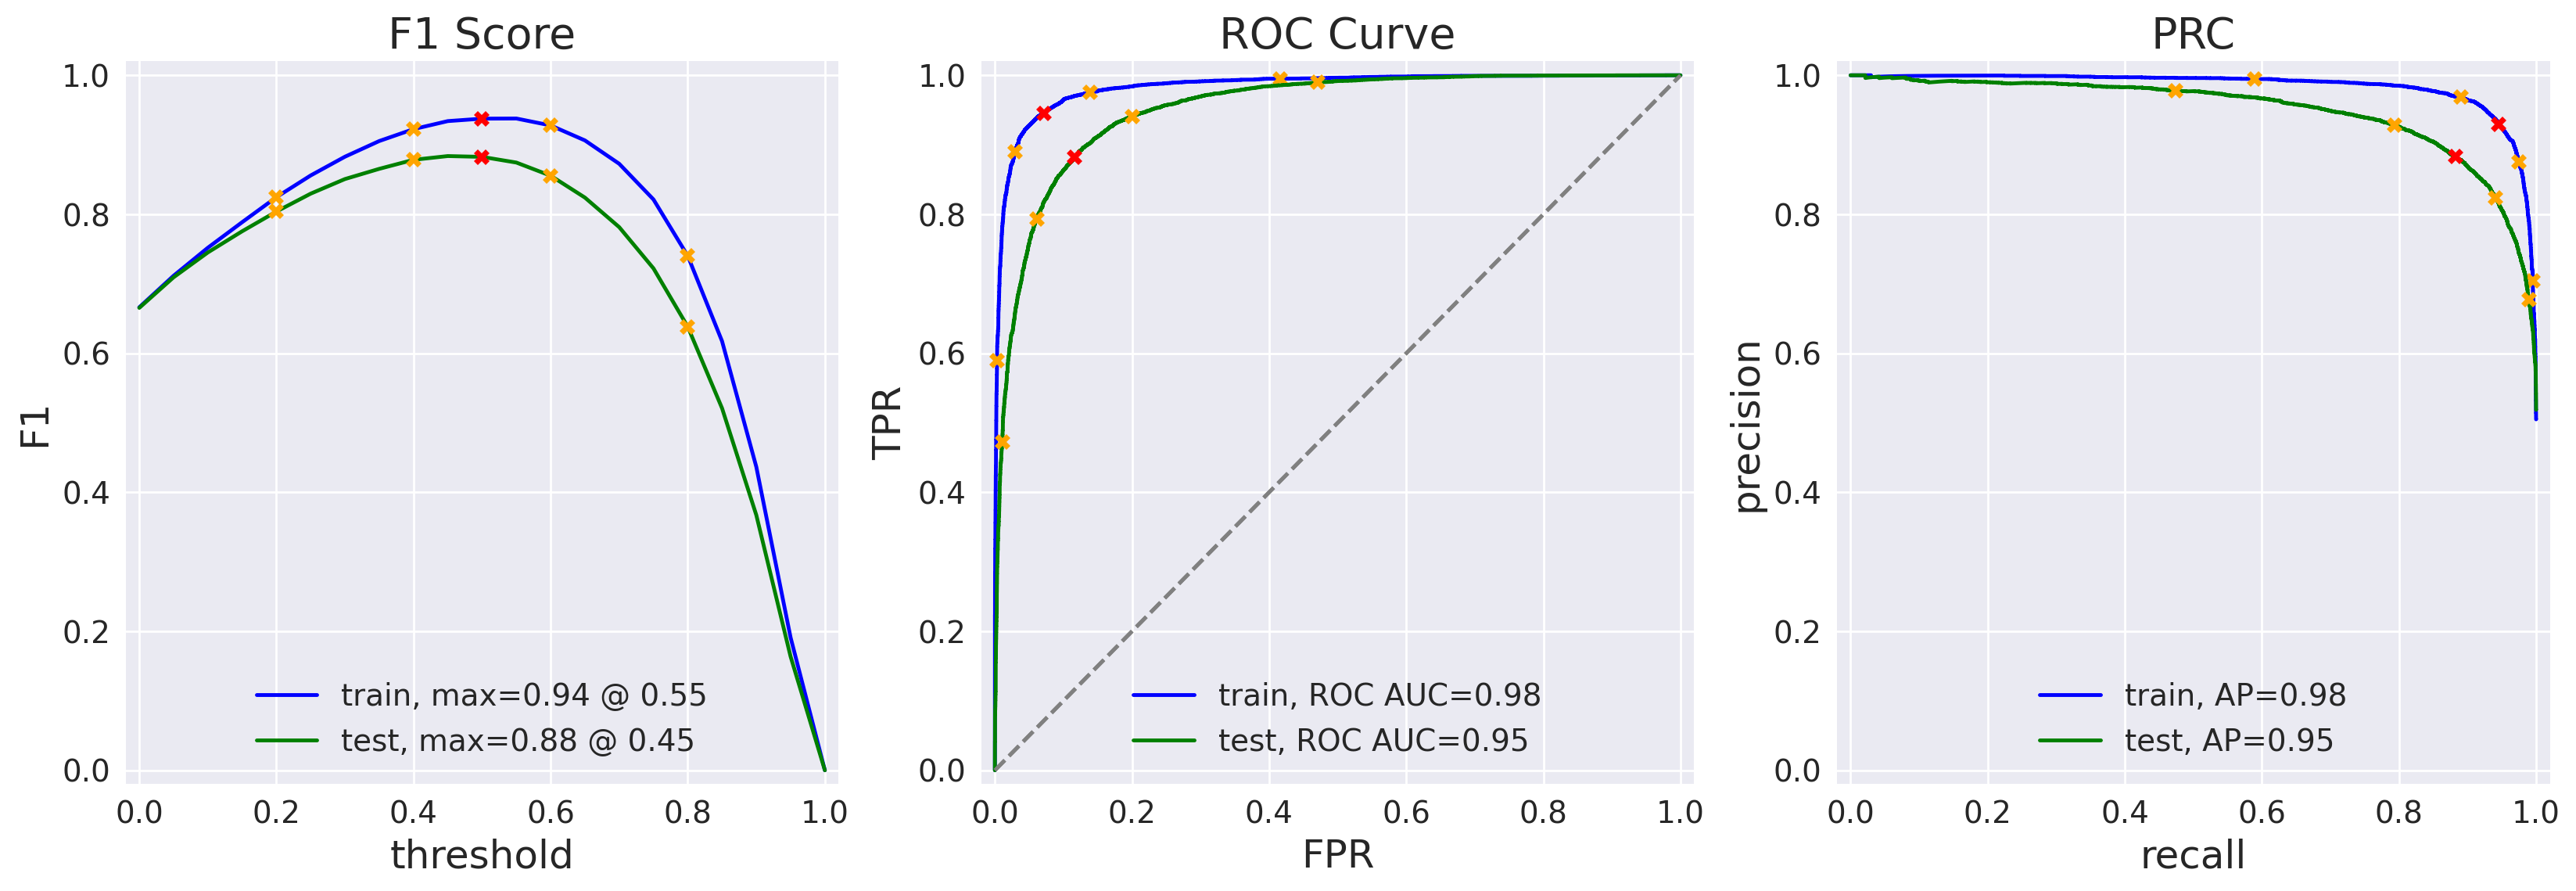

,train,test
Accuracy,0.94,0.88
F1,0.94,0.88
APS,0.98,0.95
ROC AUC,0.98,0.95


In [15]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Model 2 - TF-IDF (no NLTK) + Logistic Regression

This model tests whether removing stopwords actually helps. Here, I use TF‑IDF with no stopword filtering to see if performance changes.

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


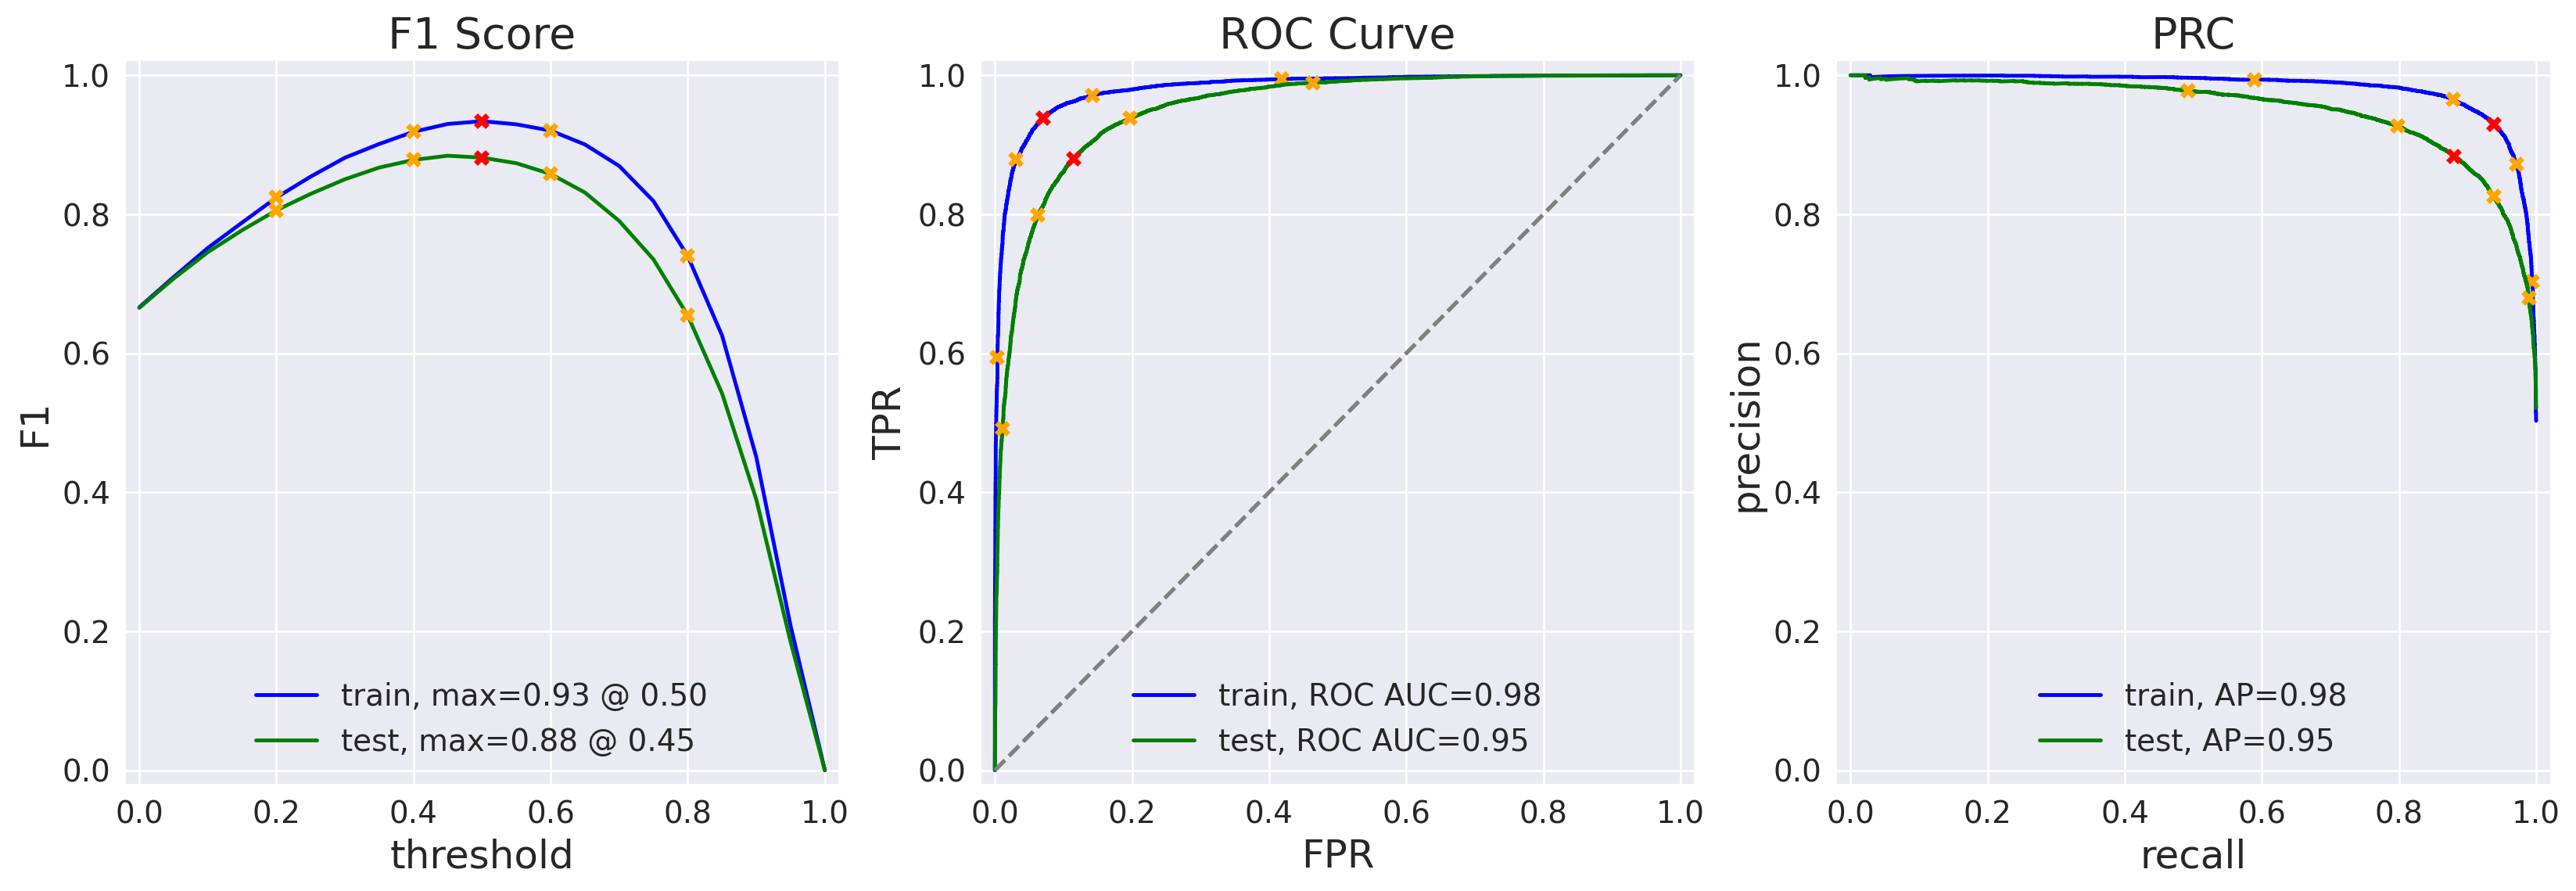

,train,test
Accuracy,0.93,0.88
F1,0.93,0.88
APS,0.98,0.95
ROC AUC,0.98,0.95


In [16]:
tfidf_vectorizer_2 = TfidfVectorizer()

train_features_2 = tfidf_vectorizer_2.fit_transform(df_reviews_train['review_norm'])
test_features_2 = tfidf_vectorizer_2.transform(df_reviews_test['review_norm'])

model_2 = LogisticRegression(max_iter=200)
model_2.fit(train_features_2, train_target)

evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

### Model 3 - spaCy, TF-IDF and LR

This model applies spaCy lemmatization to reduce words to their base forms. The goal is to see whether linguistic normalization improves performance.

Lemmatizing train data...
Processed 1000/23796 reviews
Processed 2000/23796 reviews
Processed 3000/23796 reviews
Processed 4000/23796 reviews
Processed 5000/23796 reviews
Processed 6000/23796 reviews
Processed 7000/23796 reviews
Processed 8000/23796 reviews
Processed 9000/23796 reviews
Processed 10000/23796 reviews
Processed 11000/23796 reviews
Processed 12000/23796 reviews
Processed 13000/23796 reviews
Processed 14000/23796 reviews
Processed 15000/23796 reviews
Processed 16000/23796 reviews
Processed 17000/23796 reviews
Processed 18000/23796 reviews
Processed 19000/23796 reviews
Processed 20000/23796 reviews
Processed 21000/23796 reviews
Processed 22000/23796 reviews
Processed 23000/23796 reviews
Processed 23796/23796 reviews
Lemmatizing test data...
Processed 1000/23535 reviews
Processed 2000/23535 reviews
Processed 3000/23535 reviews
Processed 4000/23535 reviews
Processed 5000/23535 reviews
Processed 6000/23535 reviews
Processed 7000/23535 reviews
Processed 8000/23535 reviews
Proces

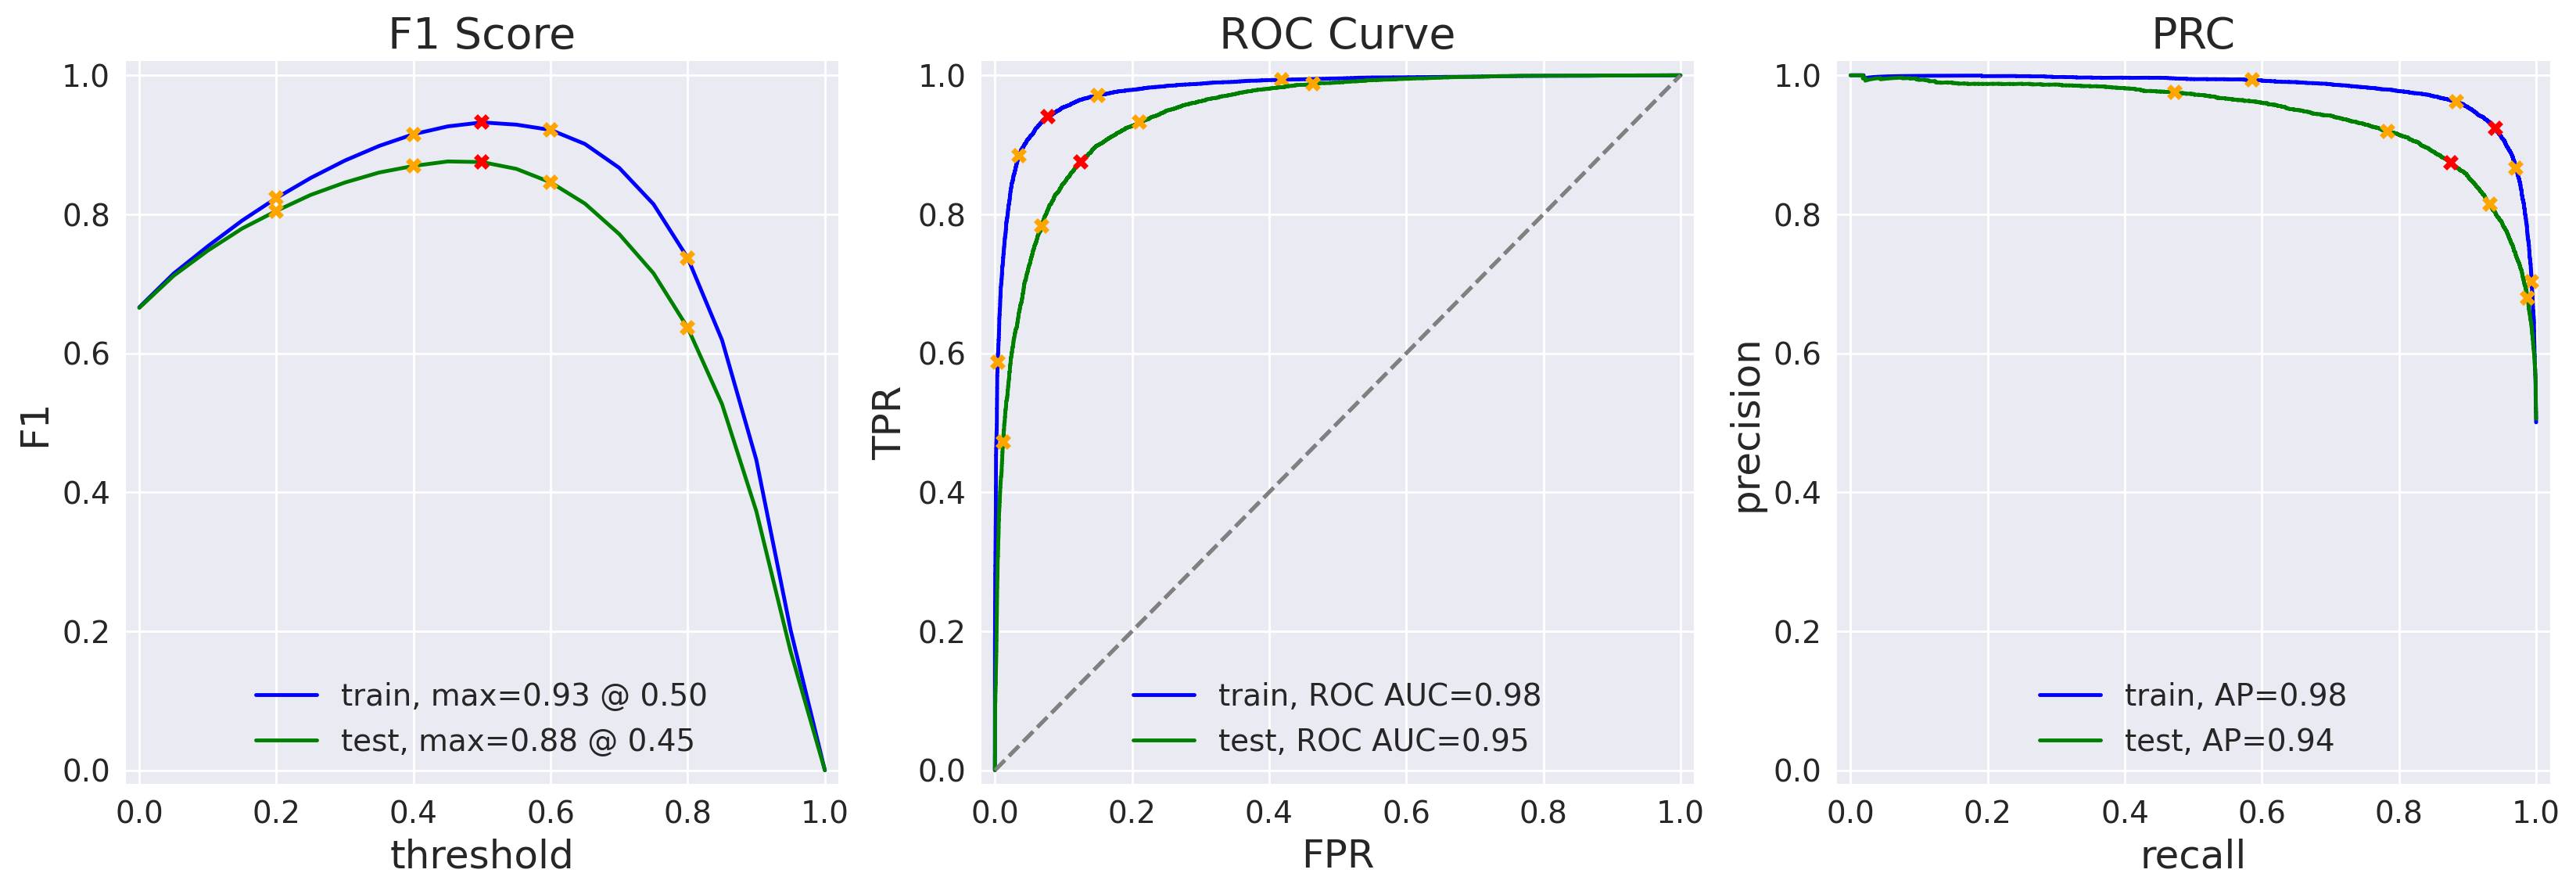

,train,test
Accuracy,0.93,0.88
F1,0.93,0.88
APS,0.98,0.94
ROC AUC,0.98,0.95


In [17]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess_pipe(texts, batch_size=100):
    lemmatized_texts = []
    
    if hasattr(texts, 'tolist'):
        text_list = texts.tolist()
    else:
        text_list = list(texts)
    
    for doc in nlp.pipe(text_list, batch_size=batch_size):
        lemmas = [token.lemma_.lower() for token in doc 
                 if not token.is_stop and not token.is_punct and token.lemma_.strip()]
        lemmatized_texts.append(' '.join(lemmas))
    
    return lemmatized_texts

def safe_lemmatize(texts, chunk_size=1000):
    all_lemmas = []
    for i in range(0, len(texts), chunk_size):
        chunk = texts.iloc[i:i+chunk_size]
        chunk_lemmas = preprocess_pipe(chunk, batch_size=100)
        all_lemmas.extend(chunk_lemmas)
        print(f"Processed {min(i+chunk_size, len(texts))}/{len(texts)} reviews")
    return all_lemmas

print("Lemmatizing train data...")
df_reviews_train['lemmatized'] = safe_lemmatize(df_reviews_train['review_norm'])
print("Lemmatizing test data...")
df_reviews_test['lemmatized'] = safe_lemmatize(df_reviews_test['review_norm'])

tfidf = TfidfVectorizer()
tfidf_train = tfidf.fit_transform(df_reviews_train['lemmatized'])
tfidf_test = tfidf.transform(df_reviews_test['lemmatized'])

model_3 = LogisticRegression(max_iter=1000)
model_3.fit(tfidf_train, df_reviews_train['pos'])

evaluate_model(model_3, tfidf_train, train_target, tfidf_test, test_target)

### Model 4 - spaCy, TF-IDF and LGBMClassifier

This model keeps the same preprocessing as Model 3 but replaces Logistic Regression with a gradient‑boosting classifier (LightGBM) to test a more flexible algorithm.

          train  test
Accuracy   0.98  0.87
F1         0.98  0.87
APS        1.00  0.94
ROC AUC    1.00  0.94


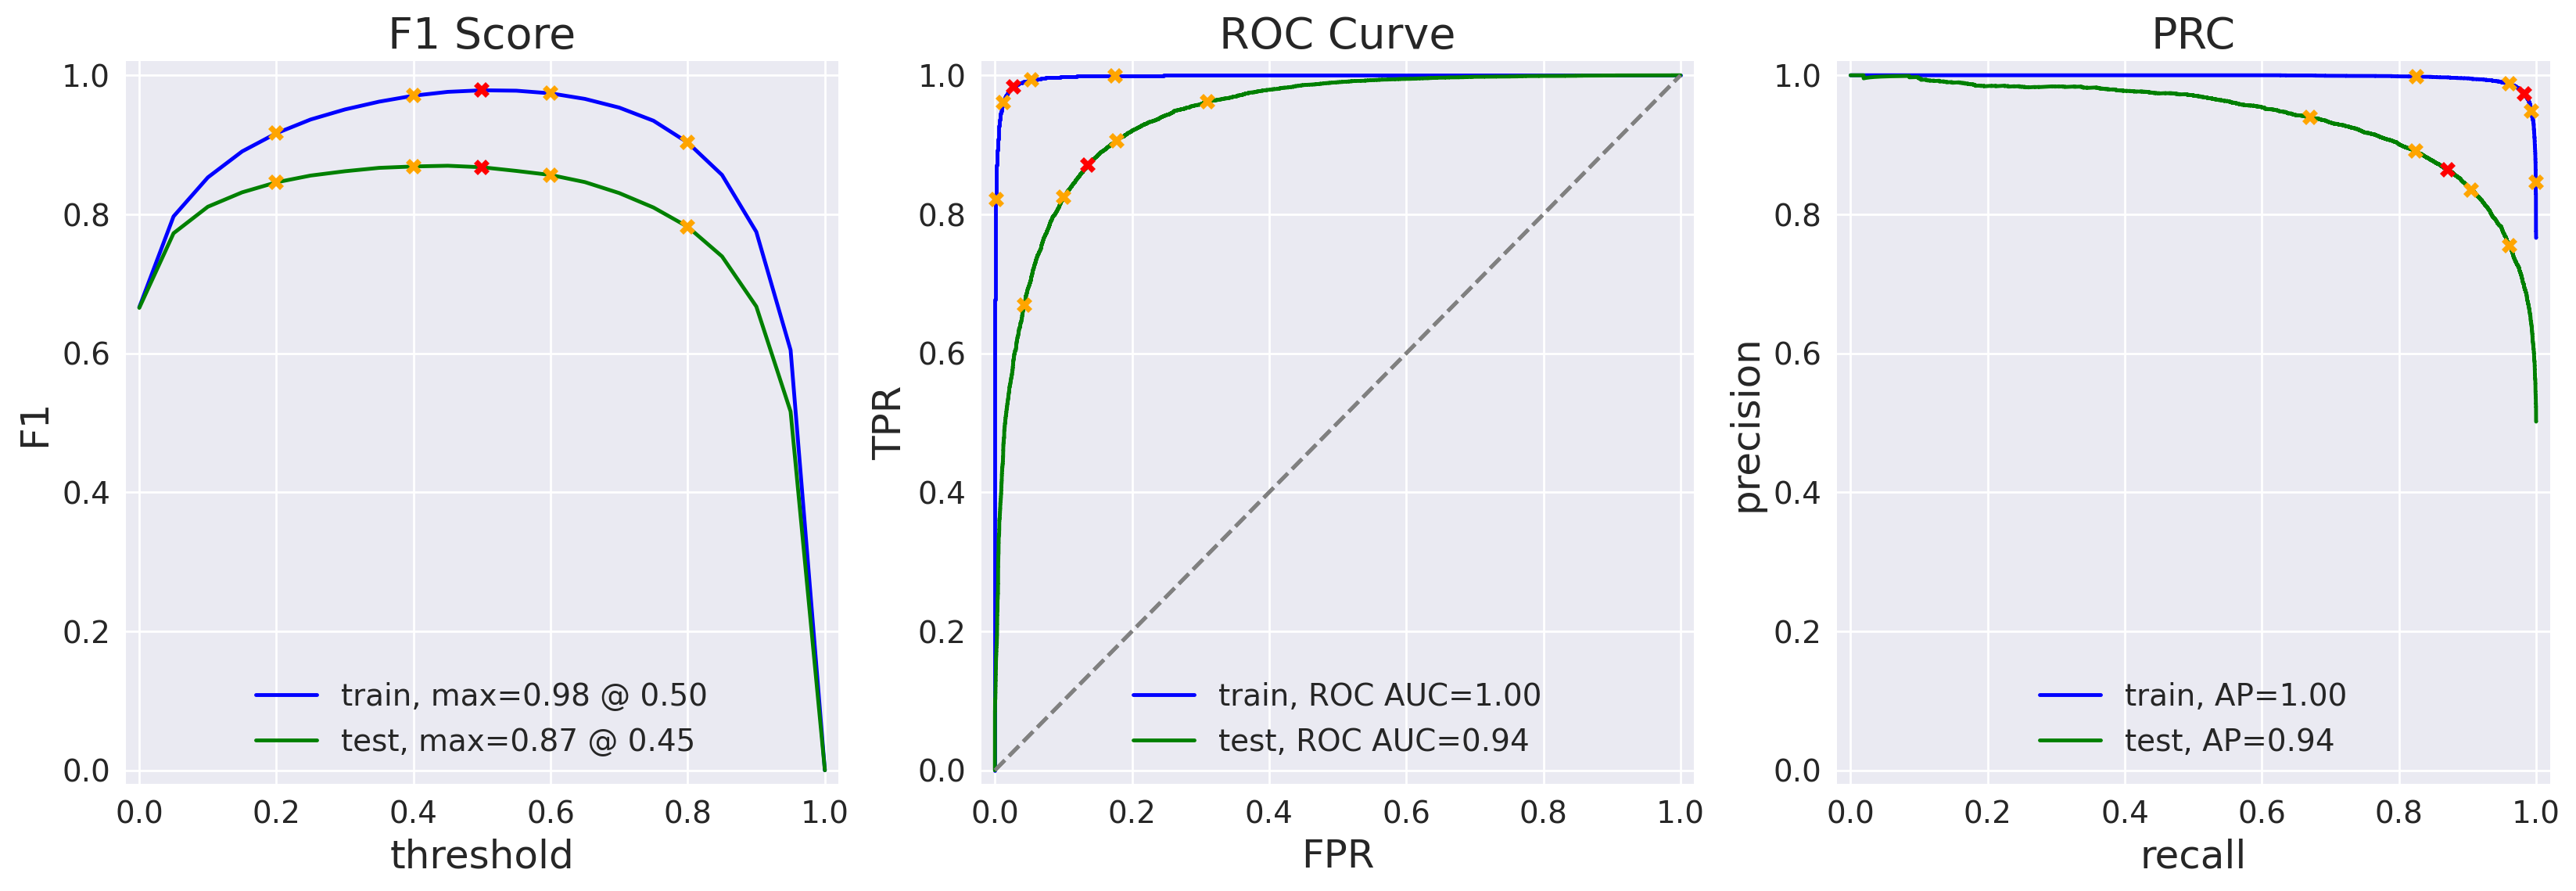

,train,test
Accuracy,0.98,0.87
F1,0.98,0.87
APS,1.00,0.94
ROC AUC,1.00,0.94


In [18]:
model_4 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

model_4.fit(tfidf_train, train_target)

evaluate_model(model_4, tfidf_train, train_target, tfidf_test, test_target)

To better understand what the LightGBM model learned, I examine the top 20 most important words.


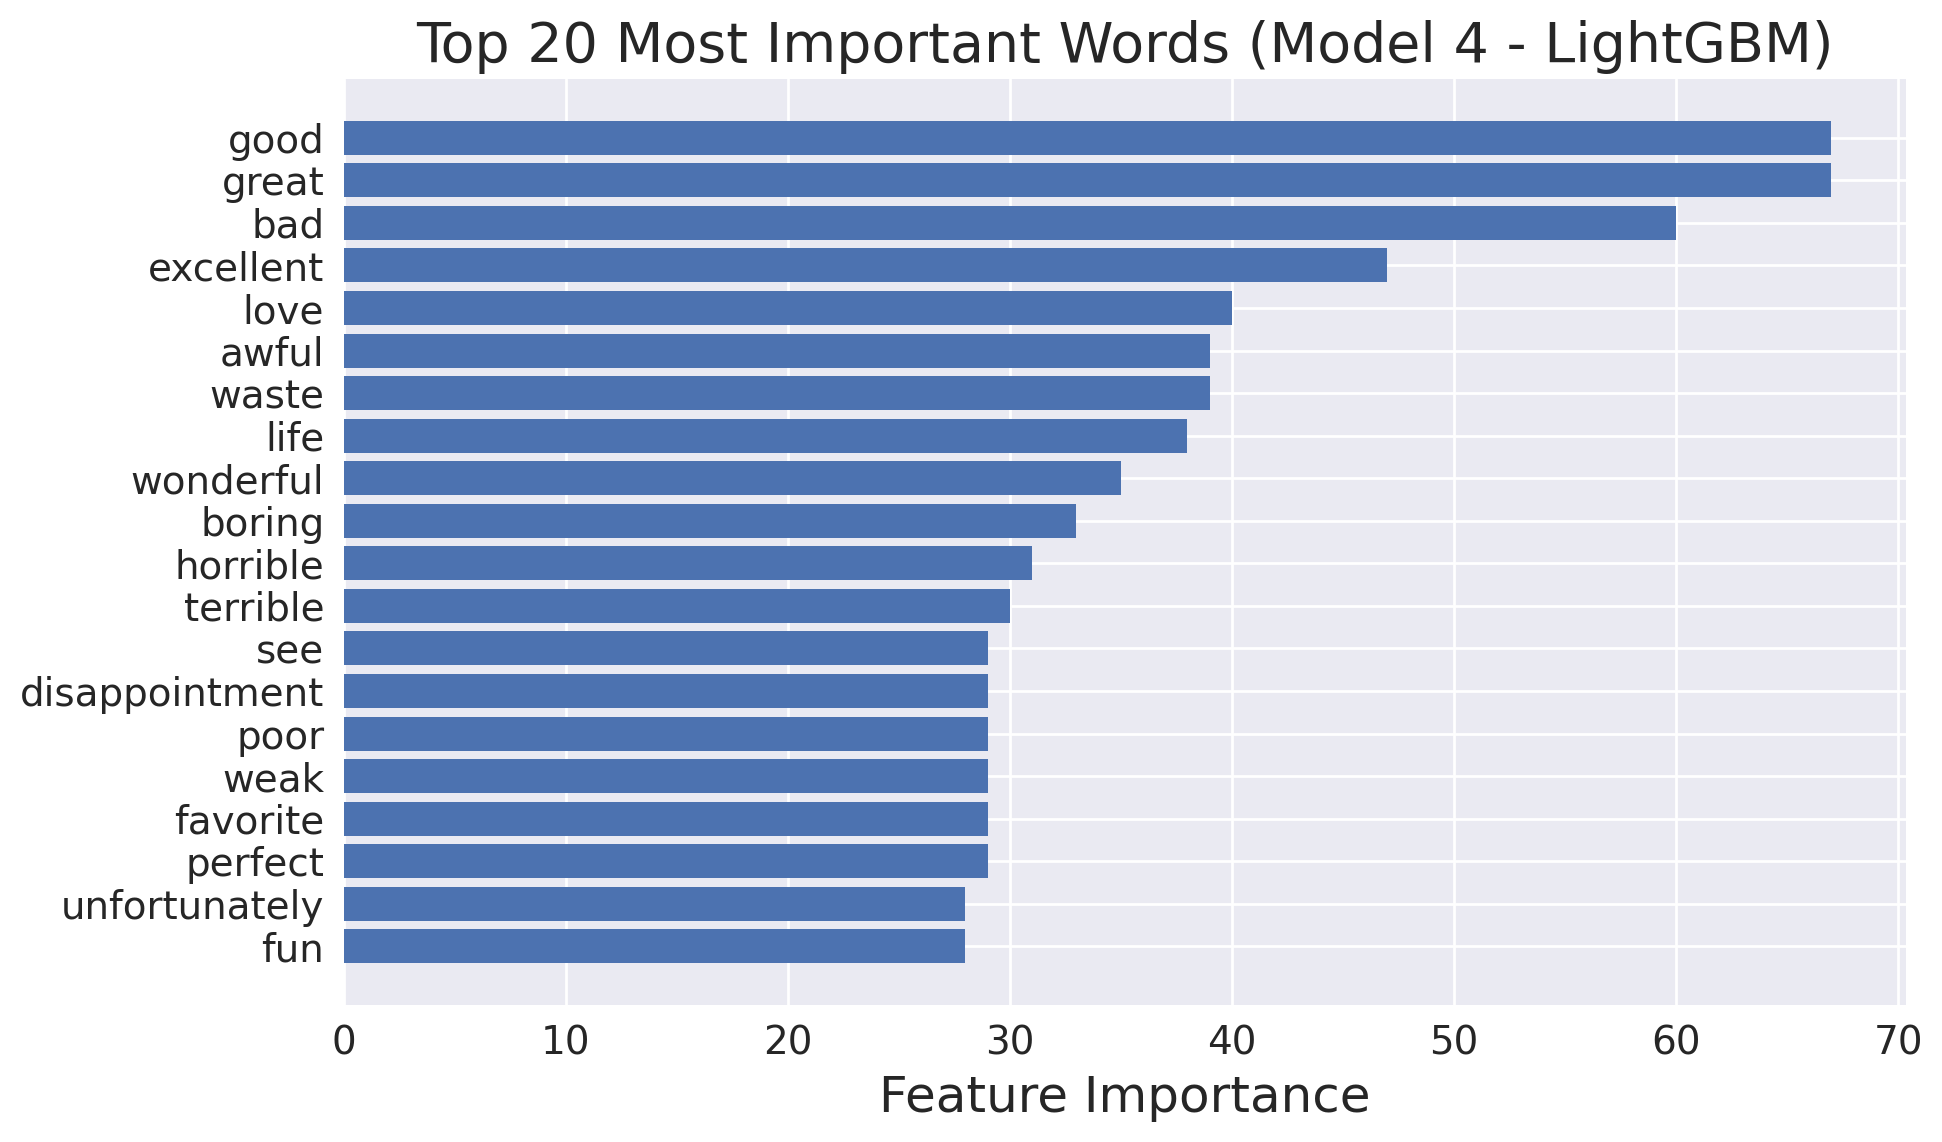

Top 10 most important words for sentiment classification:
 1. good            - 67.0000
 2. great           - 67.0000
 3. bad             - 60.0000
 4. excellent       - 47.0000
 5. love            - 40.0000
 6. awful           - 39.0000
 7. waste           - 39.0000
 8. life            - 38.0000
 9. wonderful       - 35.0000
10. boring          - 33.0000


In [19]:
feature_names = tfidf.get_feature_names()
importance = model_4.feature_importances_

top_indices = importance.argsort()[-20:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_importance = importance[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_words)), top_importance)
plt.yticks(range(len(top_words)), top_words)
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Words (Model 4 - LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 most important words for sentiment classification:")
for i, (word, importance) in enumerate(zip(top_words[:10], top_importance[:10])):
    print(f"{i+1:2d}. {word:15s} - {importance:.4f}")

## My Reviews

In [20]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.',
    'This was way better than I expected, I was smiling through the whole third act.',
    'I checked my phone ten times during the movie. That’s how boring it was.'
], columns=['review'])

my_reviews['review_norm'] = (
    my_reviews['review']
        .str.lower()
        .str.replace(r'[^a-z\s]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...
8,"This was way better than I expected, I was smi...",this was way better than i expected i was smil...
9,I checked my phone ten times during the movie....,i checked my phone ten times during the movie ...


### Model 1 Predictions

In [21]:
texts = my_reviews['review_norm']
my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.14:  i did not simply like it not my kind of movie
0.16:  well i was bored and felt asleep in the middle of the movie
0.54:  i was really fascinated with the movie
0.11:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.31:  i didn t expect the reboot to be so good writers really cared about the source material
0.47:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.82:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo
0.32:  this was way better than i expected i was smiling through the whole third act
0.16:  i checked my phone ten times during the movie that s how boring it was


### Model 2 Predictions

In [22]:
texts = my_reviews['review_norm']
my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.15:  i did not simply like it not my kind of movie
0.24:  well i was bored and felt asleep in the middle of the movie
0.47:  i was really fascinated with the movie
0.15:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.22:  i didn t expect the reboot to be so good writers really cared about the source material
0.63:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.73:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo
0.19:  this was way better than i expected i was smiling through the whole third act
0.23:  i checked my phone ten times during the movie that s how boring it was


### Model 3 Predictions

In [23]:
texts = my_reviews['review_norm']
lemm_texts = preprocess_pipe(texts)
my_reviews_pred_prob = model_3.predict_proba(tfidf.transform(lemm_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.19:  i did not simply like it not my kind of movie
0.07:  well i was bored and felt asleep in the middle of the movie
0.50:  i was really fascinated with the movie
0.15:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.19:  i didn t expect the reboot to be so good writers really cared about the source material
0.41:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.91:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo
0.48:  this was way better than i expected i was smiling through the whole third act
0.09:  i checked my phone ten times during the movie that s how boring it was


### Model 4 Predictions

In [24]:
texts = my_reviews['review_norm']
lemm_texts = preprocess_pipe(texts)
my_reviews_pred_prob = model_4.predict_proba(tfidf.transform(lemm_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.55:  i did not simply like it not my kind of movie
0.15:  well i was bored and felt asleep in the middle of the movie
0.56:  i was really fascinated with the movie
0.27:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.33:  i didn t expect the reboot to be so good writers really cared about the source material
0.58:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.20:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.91:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo
0.48:  this was way better than i expected i was smiling through the whole third act
0.10:  i checked my phone ten times during the movie that s how boring it was


### Model Comparison Summary

The table below summarizes the performance of all four models on the test set.  
Metrics include F1 score, ROC AUC, and a qualitative assessment of overfitting.


In [25]:
models_summary = pd.DataFrame({
    'Model': ['Model 1 (NLTK)', 'Model 2 (Basic)', 'Model 3 (spaCy)', 'Model 4 (LightGBM)'],
    'Preprocessing': ['NLTK stopwords', 'Basic TF-IDF', 'spaCy lemmatization', 'spaCy lemmatization'],
    'Algorithm': ['LogisticRegression', 'LogisticRegression', 'LogisticRegression', 'LightGBM'],
    'Test F1': [0.88, 0.88, 0.88, 0.87],
    'Test ROC AUC': [0.95, 0.95, 0.95, 0.94],
    'Overfitting': ['Low', 'Low', 'Low', 'High']
})

print("Model Performance Comparison:")
print(models_summary.to_string(index=False))

Model Performance Comparison:
             Model       Preprocessing          Algorithm  Test F1  Test ROC AUC Overfitting
    Model 1 (NLTK)      NLTK stopwords LogisticRegression     0.88          0.95         Low
   Model 2 (Basic)        Basic TF-IDF LogisticRegression     0.88          0.95         Low
   Model 3 (spaCy) spaCy lemmatization LogisticRegression     0.88          0.95         Low
Model 4 (LightGBM) spaCy lemmatization           LightGBM     0.87          0.94        High


### Error Analysis

To better understand model behavior, I examined misclassified reviews from the test set.  
This highlights patterns in false positives and false negatives and helps identify potential areas for improvement.

In [26]:
preds_test = model_2.predict(test_features_2)
misclassified_indices = df_reviews_test[preds_test != test_target].index

print("Error Analysis for Model 2:")
print(f"Total misclassified: {len(misclassified_indices)} out of {len(test_target)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(test_target):.1%}")

false_positives = df_reviews_test[(preds_test == 1) & (test_target == 0)]
print(f"\nFalse Positives: {len(false_positives)}")
print("Examples of reviews predicted as positive but actually negative:")
for i, (idx, row) in enumerate(false_positives.head(2).iterrows()):
    print(f"\n{i+1}. Rating: {row['rating']}/10")
    print(f"   Review: {row['review'][:200]}...")
  
false_negatives = df_reviews_test[(preds_test == 0) & (test_target == 1)]
print(f"\nFalse Negatives: {len(false_negatives)}")
print("Examples of reviews predicted as negative but actually positive:")
for i, (idx, row) in enumerate(false_negatives.head(2).iterrows()):
    print(f"\n{i+1}. Rating: {row['rating']}/10")
    print(f"   Review: {row['review'][:200]}...")

Error Analysis for Model 2:
Total misclassified: 2775 out of 23535
Misclassification rate: 11.8%

False Positives: 1362
Examples of reviews predicted as positive but actually negative:

1. Rating: 4/10
   Review: Below average blaxpoitation action / melodrama in which the lovely Ms. Grier plays a private eye who comes to the aid of her father (Rudy Challenger) and his partner (Austin Stoker of the original "As...

2. Rating: 3/10
   Review: This movie starts off on the wrong foot and never really gets it going. The first scene shows a Life Flight helicopter landing and just outside the window you can distinctly see mountains in the backg...

False Negatives: 1413
Examples of reviews predicted as negative but actually positive:

1. Rating: 7/10
   Review: If anything, William Girdler was an opportunist who wanted a piece of the action in regards to whatever was popular during the time. I mean, a blaxploitation flick in Louisville, Kentucky..who would o...

2. Rating: 8/10
   Review: She

## Conclusions

In this project, I built and evaluated four machine‑learning models for classifying IMDB movie reviews as positive or negative. All models exceeded the required F1 score of 0.85 on the test set.

#### Key Findings:

- Models 1, 2, and 3 all achieved F1 = 0.88 with very similar ROC AUC values (0.95).

- Model 4 (LightGBM) achieved F1 = 0.87 and showed clear overfitting (train F1 = 0.98).

- spaCy lemmatization did not improve performance compared to simpler preprocessing.

- Stopword removal also did not significantly change results.

Logistic Regression proved to be a strong, stable baseline across all preprocessing strategies.

#### Recommended Model

**Model 2 (Basic TF‑IDF + Logistic Regression)** is the best choice for deployment because:

- It achieves excellent performance (F1 = 0.88)

- It is simple and fast

- It has no external dependencies (unlike spaCy)

- It generalizes well without overfitting

#### Business Impact

A reliable sentiment‑classification model allows the Film Junky Union to automatically flag negative reviews, improving moderation efficiency and enhancing user experience.